## Importing the packages

In [1]:
import numpy as np
import pandas as pd
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## Loading the dataset

In [2]:
data=pd.read_csv("sleep_data_clean.csv")

In [3]:
data

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NaN,126.0,83.0
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125.0,80.0
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125.0,80.0
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140.0,90.0
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140.0,90.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140.0,95.0
370,Female,59,Nurse,8.0,9,75,3,Overweight,68,7000,Sleep Apnea,140.0,95.0
371,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140.0,95.0
372,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140.0,95.0


In [4]:
data.shape

(374, 13)

In [5]:
data["Sleep Disorder"].value_counts()

Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64

### Checking the data types

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    object 
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           155 non-null    object 
 11  Systolic_BP              374 non-null    float64
 12  Diastolic_BP             374 non-null    float64
dtypes: float64(3), int64(6), object(4)
memory usage: 38.1+ KB


In [7]:
data.describe()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920,128.553476,84.649733
std,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679,7.748118,6.161611
min,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000,115.000000,75.000000
25%,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000,125.000000,80.000000
50%,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000,130.000000,85.000000
75%,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000,135.000000,90.000000
max,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000,142.000000,95.000000


## Data pre-processing

In [8]:
data["Sleep Disorder"].value_counts()

Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64

In [9]:
new_df = data
new_df["Sleep Disorder"] = new_df["Sleep Disorder"].fillna("No Disorder")
new_df

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,No Disorder,126.0,83.0
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,No Disorder,125.0,80.0
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,No Disorder,125.0,80.0
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140.0,90.0
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140.0,90.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140.0,95.0
370,Female,59,Nurse,8.0,9,75,3,Overweight,68,7000,Sleep Apnea,140.0,95.0
371,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140.0,95.0
372,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140.0,95.0


In [10]:
new_df.isnull().sum()

Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
Systolic_BP                0
Diastolic_BP               0
dtype: int64

In [11]:
print("Gender:", new_df["Gender"].unique())
print("Occupation:", new_df["Occupation"].unique())
print("BMI Category:", new_df["BMI Category"].unique())

gender_map = {
    "Male": 0,
    "Female": 1
}

occupation_map = {
    "Software Engineer": 0,
    "Doctor": 1,
    "Sales Representative": 2,
    "Teacher": 3,
    "Nurse": 4,
    "Engineer": 5,
    "Accountant": 6,
    "Scientist": 7,
    "Lawyer": 8,
    "Salesperson": 9,
    "Manager": 10
}

bmi_map = {
    "Underweight": 0,   # only if it exists
    "Normal": 1,
    "Normal Weight": 1, # treating both as same meaning
    "Overweight": 2,
    "Obese": 3
}

# ---------- APPLY ENCODING ----------
new_df["Gender"] = new_df["Gender"].map(gender_map)
new_df["Occupation"] = new_df["Occupation"].map(occupation_map)
new_df["BMI Category"] = new_df["BMI Category"].map(bmi_map)

Gender: ['Male' 'Female']
Occupation: ['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager']
BMI Category: ['Overweight' 'Normal' 'Obese' 'Normal Weight']


In [12]:
sleep_map = {
    "No Disorder": 0,
    "Sleep Apnea": 1,
    "Insomnia": 2,
    "None": 0   # optional — ONLY if you want your earlier "None" to mean no disorder
}

new_df["Sleep Disorder"] = new_df["Sleep Disorder"].map(sleep_map)

In [13]:
new_df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,0,27,0,6.1,6,42,6,2,77,4200,0,126.0,83.0
1,0,28,1,6.2,6,60,8,1,75,10000,0,125.0,80.0
2,0,28,1,6.2,6,60,8,1,75,10000,0,125.0,80.0
3,0,28,2,5.9,4,30,8,3,85,3000,1,140.0,90.0
4,0,28,2,5.9,4,30,8,3,85,3000,1,140.0,90.0


In [14]:
X = new_df.drop(columns=['Sleep Disorder'],axis=1)
Y = new_df['Sleep Disorder']

In [15]:
X.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP
0,0,27,0,6.1,6,42,6,2,77,4200,126.0,83.0
1,0,28,1,6.2,6,60,8,1,75,10000,125.0,80.0
2,0,28,1,6.2,6,60,8,1,75,10000,125.0,80.0
3,0,28,2,5.9,4,30,8,3,85,3000,140.0,90.0
4,0,28,2,5.9,4,30,8,3,85,3000,140.0,90.0


In [16]:
Y.head()

0    0
1    0
2    0
3    1
4    1
Name: Sleep Disorder, dtype: int64

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test,Y_train,Y_test = train_test_split(X,Y,stratify=Y,test_size=0.1,random_state=2)

In [18]:
X_test

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP
210,0,43,5,7.7,8,90,5,1,70,8000,130.0,85.0
337,1,54,5,8.4,9,30,3,1,65,5000,125.0,80.0
74,0,33,1,6.0,6,30,8,1,72,5000,125.0,80.0
171,0,41,8,7.7,8,90,5,1,70,8000,130.0,85.0
142,1,38,6,7.1,8,60,4,1,68,7000,115.0,75.0
227,0,44,9,6.3,6,45,7,2,72,6000,130.0,85.0
11,0,29,1,7.8,7,75,6,1,70,8000,120.0,80.0
40,0,31,1,7.7,7,75,6,1,70,8000,120.0,80.0
348,1,57,4,8.2,9,75,3,2,68,7000,140.0,95.0
205,0,43,5,7.7,8,90,5,1,70,8000,130.0,85.0


In [19]:
Y_test

210    0
337    0
74     0
171    0
142    0
227    2
11     0
40     0
348    1
205    0
30     1
234    2
292    1
22     0
122    0
94     2
57     0
289    1
356    1
85     0
113    0
320    0
261    0
177    2
29     0
258    2
4      1
31     2
46     0
134    0
53     0
357    1
88     0
211    0
235    2
287    1
335    0
315    2
Name: Sleep Disorder, dtype: int64

In [20]:
print(X.shape,X_train.shape,X_test.shape)

(374, 12) (336, 12) (38, 12)


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [22]:
models = [LogisticRegression(random_state = 0),KNeighborsClassifier(n_neighbors=30),ExtraTreesClassifier(n_estimators=15, random_state=42,max_features="log2"),GaussianNB(),DecisionTreeClassifier(random_state = 0),RandomForestClassifier(random_state = 0)]
models_name=["Logistic Regression","KNeighbors Classifier","ExtraTrees Classifier","GaussianNB","DecisionTree Classifier","RandomForest Classifier"]

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
score=[]
def compare_models(models):
    i=0
    for model in models:
        
        model.fit(X_train,Y_train)
        y_pred=model.predict(X_test)
       
        accuracy = accuracy_score(Y_test, y_pred)
        classification_rep = classification_report(Y_test, y_pred)
        conf_matrix = confusion_matrix(Y_test, y_pred)
        score.append(accuracy)
        
        print(f"Accuracy of {models_name[i]}")
        print(f"Accuracy: {accuracy:.4f}")
        print("\nConfusion Matrix:\n", conf_matrix)
        print("\nClassification Report:\n", classification_rep)
        print("------------------------------------------------------")
        i+=1

In [24]:
compare_models(models)

Accuracy of Logistic Regression
Accuracy: 0.7105

Confusion Matrix:
 [[18  0  4]
 [ 2  6  0]
 [ 5  0  3]]

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.82      0.77        22
           1       1.00      0.75      0.86         8
           2       0.43      0.38      0.40         8

    accuracy                           0.71        38
   macro avg       0.72      0.65      0.67        38
weighted avg       0.72      0.71      0.71        38

------------------------------------------------------
Accuracy of KNeighbors Classifier
Accuracy: 0.8421

Confusion Matrix:
 [[21  0  1]
 [ 2  6  0]
 [ 3  0  5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.95      0.88        22
           1       1.00      0.75      0.86         8
           2       0.83      0.62      0.71         8

    accuracy                           0.84        38
   macro avg       0.88     

In [25]:
score

[0.7105263157894737,
 0.8421052631578947,
 0.8947368421052632,
 0.8947368421052632,
 0.8947368421052632,
 0.8947368421052632]

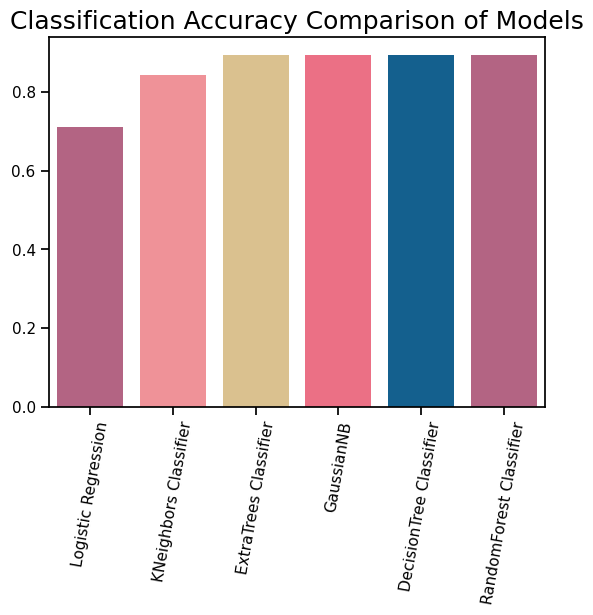

In [26]:
sns.set(context='notebook', style=None)
ax = sns.barplot(x=models_name, y=score, palette=['#C05780','#FF828B','#E7C582','#FF5C77','#0065A2'])
ax.set_title('Classification Accuracy Comparison of Models', fontsize=18)
for item in ax.get_xticklabels():
    item.set_rotation(80)
for p in ax.patches:
        ax.annotate('{:}%'.format(p.get_height()), (p.get_x()+0.01, p.get_height()+1))

In [27]:
model=ExtraTreesClassifier(n_estimators=15, random_state=42,max_features="log2")

In [28]:
model.fit(X_train,Y_train)

ExtraTreesClassifier(max_features='log2', n_estimators=15, random_state=42)

In [29]:
X_test

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP
210,0,43,5,7.7,8,90,5,1,70,8000,130.0,85.0
337,1,54,5,8.4,9,30,3,1,65,5000,125.0,80.0
74,0,33,1,6.0,6,30,8,1,72,5000,125.0,80.0
171,0,41,8,7.7,8,90,5,1,70,8000,130.0,85.0
142,1,38,6,7.1,8,60,4,1,68,7000,115.0,75.0
227,0,44,9,6.3,6,45,7,2,72,6000,130.0,85.0
11,0,29,1,7.8,7,75,6,1,70,8000,120.0,80.0
40,0,31,1,7.7,7,75,6,1,70,8000,120.0,80.0
348,1,57,4,8.2,9,75,3,2,68,7000,140.0,95.0
205,0,43,5,7.7,8,90,5,1,70,8000,130.0,85.0


In [30]:
Y_test

210    0
337    0
74     0
171    0
142    0
227    2
11     0
40     0
348    1
205    0
30     1
234    2
292    1
22     0
122    0
94     2
57     0
289    1
356    1
85     0
113    0
320    0
261    0
177    2
29     0
258    2
4      1
31     2
46     0
134    0
53     0
357    1
88     0
211    0
235    2
287    1
335    0
315    2
Name: Sleep Disorder, dtype: int64

In [33]:
#making a predictive system
input_data=(0,31,1,7.8,7,75,6,1,70,8000,120.0,80.0)

#changing the input data to numpy array
input_data_as_numpy_array=np.asarray(input_data)

#reshape the array as we are predicting for one instance
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

prediction=model.predict(input_data_reshaped)
print(prediction)

if(prediction[0]==0):
    print("The person doesn\'t suffer any Sleep Disorder")
elif(prediction[0] == 1):
    print("The person suffers Sleep Apnea.")
else:
    print("The person suffers Insomnia.")

[0]
The person doesn't suffer any Sleep Disorder


In [35]:
#making a predictive system
input_data=(1,45,3,6.8,7,30,6,2,65,6000,135.0,90.0)

#changing the input data to numpy array
input_data_as_numpy_array=np.asarray(input_data)

#reshape the array as we are predicting for one instance
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

prediction=model.predict(input_data_reshaped)
print(prediction)

if(prediction[0]==0):
    print("The person doesn\'t suffer any Sleep Disorder")
elif(prediction[0] == 1):
    print("The person suffers Sleep Apnea.")
else:
    print("The person suffers Insomnia.")

[2]
The person suffers Insomnia.


In [36]:
import pickle

In [37]:
filename='insomnia_model.pkl'
pickle.dump(model,open(filename,'wb'))

In [38]:
loaded_model=pickle.load(open("insomnia_model.pkl",'rb'))

In [39]:
#making a predictive system
input_data=(1,49,4,6.0,6,90,8,2,75,10000,140.0,95.0)

#changing the input data to numpy array
input_data_as_numpy_array=np.asarray(input_data)

#reshape the array as we are predicting for one instance
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

prediction=loaded_model.predict(input_data_reshaped)
print(prediction)

if(prediction[0]==0):
    print("The person doesn\'t suffer any Sleep Disorder")
elif(prediction[0] == 1):
    print("The person suffers Sleep Apnea.")
else:
    print("The person suffers Insomnia.")

[1]
The person suffers Sleep Apnea.
